## 1. What this notebook computes

The pairing theorem T1 of the Revision record says that the chirality matrix
$\Gamma = \gamma^{(x_8)}\gamma^{(x_1)}\cdots\gamma^{(x_7)}$ turns every solution
$\Psi$ of the field of mass $m$ (and coupling $\lambda$) into a solution
$\Gamma\Psi$ of the field of mass $-m$ (and coupling $-\lambda$), with the
energy-momentum tensor and the current reversed: $T \to -T$, $J \to -J$. What
does this mean once dirac16complex is QUANTISED? The Revision pairing record
answers with five statements, the *quantum reading* Q. This notebook checks the
four of them that concern the canonical anticommutator, exactly with sympy and on
explicit fermionic Fock spaces (the fifth, about one-particle spectra, is the
subject of the first notebook of this chapter). It

- proves the Lagrangian identity $\mathcal{L}_m[\Gamma\chi] = -\mathcal{L}_{-m}[\chi]$
  for symbolic field components, and computes the time-derivative kernels of three
  Lagrangians: that of the field $\Psi$, that of its chirality image $\chi =
  \Gamma\Psi$ (the same system written in new variables) and that of an
  independent universe of mass $-m$; they force the canonical anticommutators
  $+B$, $-B$ and $+B$;
- checks on a Fock space that the image $\Gamma\Psi$ carries the Krein metric $-B$,
  while the mirror image $\gamma^{(x_8)}\Psi$ of theorem T2 keeps $+B$;
- checks that the energy and the charge of the field are MINUS the energy and the
  charge that the mass $-m$ theory assigns to the image: $T \to -T$ and $J \to -J$
  hold as identities between operators of ONE quantum system;
- builds two independently quantised universes of masses $+m$ and $-m$ on one Fock
  space and checks that each has the anticommutator $+B$, that they anticommute
  with each other, and that the image $\Gamma\Psi$ cannot be one of them;
- shows that their energies ADD and never cancel: the block generator has the
  eigenvalues $+m$ and $-m$ (16 each, none zero), and for one good-sector momentum
  every state of the two universes has a total energy of at least 0, while a pair
  of total charge 0 has the energy $2E$, not 0;
- reproduces the corresponding checks of the Revision record and draws five
  teaching figures.

Nothing here describes the CREATION of a universe or of a pair: the statements are
about how the canonical rule treats a solution, its image and a second universe.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 10g (The quantum reading of the pairing: one system or two universes) is the
file `Revision/textbook/notebooks/10g_quantum_pair_reading.ipynb` of the repository
Dirac_claude. It checks, exactly with sympy and on explicit fermionic Fock spaces, the
quantum reading Q of the Revision pairing record: the Lagrangian identity L_m of Gamma
chi equals minus L_-m of chi, the time-derivative kernels of the three Lagrangians
involved (the field, its chirality image, an independent universe of mass -m), the
canonical anticommutators they force (+B, -B, +B), that the chirality image Gamma Psi
carries the Krein metric -B and the mirror image keeps +B, that the energy and the charge
of the field are minus those that the mass -m theory assigns to its image (one quantum
system, T to -T and J to -J as operator identities), that two independently quantised
universes of masses +m and -m have the anticommutator +B each, anticommute with each
other and cannot be identified with the image, and that their generators add without
cancelling (block eigenvalues +m and -m, 16 each; one good-sector momentum: every state
of the product Fock space has a non-negative total energy, a pair of zero total charge
has energy 2E); five teaching figures. It needs a computer with Windows 11, macOS or
Linux, an internet connection for the installation, the program Git, and Python 3.12 or
newer (the notebooks were built with Python 3.14.5) with these packages at exactly these
versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10,
nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook
itself imports numpy, sympy and matplotlib; the other packages run Jupyter, the program
that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 10g_quantum_pair_reading.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 10g_quantum_pair_reading.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
10g_quantum_pair_reading.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/10g.captions.json`
- `Revision/textbook/figures/10g_1_krein_metrics.png`
- `Revision/textbook/figures/10g_2_one_system.png`
- `Revision/textbook/figures/10g_3_anticommutator_blocks.png`
- `Revision/textbook/figures/10g_4_block_generator.png`
- `Revision/textbook/figures/10g_5_two_universe_states.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the figure file 10g_5_two_universe_states.png exists
    ALL 30 CHECKS PASSED (notebook 10g)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/10g_quantum_pair_reading.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 10g_quantum_pair_reading.ipynb
      python -m nbconvert --execute --inplace 10g_quantum_pair_reading.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for a file below the folder Revision: the notebook reads files of
  the Revision record: the data it starts from and the report files whose checks it
  reproduces (each cited check must still exist there with the verdict PASS). It must be
  opened inside the folder Revision/textbook/notebooks of a complete copy of the
  repository (a notebook copied alone to another folder cannot find them). Clone the
  repository again and open the notebook there.
- "AssertionError: the cited record check is missing or not PASS": a report file of the
  Revision record no longer holds the check that the notebook names, or holds it with
  another verdict: the copy of the repository is incomplete or was changed. Clone the
  repository again and open the notebook there.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 10g (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 10g (The quantum reading of the pairing: one system or two universes) is the
# file Revision/textbook/notebooks/10g_quantum_pair_reading.ipynb of the repository
# Dirac_claude. It checks, exactly with sympy and on explicit fermionic Fock spaces, the
# quantum reading Q of the Revision pairing record: the Lagrangian identity L_m of Gamma
# chi equals minus L_-m of chi, the time-derivative kernels of the three Lagrangians
# involved (the field, its chirality image, an independent universe of mass -m), the
# canonical anticommutators they force (+B, -B, +B), that the chirality image Gamma Psi
# carries the Krein metric -B and the mirror image keeps +B, that the energy and the
# charge of the field are minus those that the mass -m theory assigns to its image (one
# quantum system, T to -T and J to -J as operator identities), that two independently
# quantised universes of masses +m and -m have the anticommutator +B each, anticommute
# with each other and cannot be identified with the image, and that their generators add
# without cancelling (block eigenvalues +m and -m, 16 each; one good-sector momentum:
# every state of the product Fock space has a non-negative total energy, a pair of zero
# total charge has energy 2E); five teaching figures. It needs a computer with Windows
# 11, macOS or Linux, an internet connection for the installation, the program Git, and
# Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages
# at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
# jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
# 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 10g_quantum_pair_reading.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 10g_quantum_pair_reading.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 10g_quantum_pair_reading.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/10g.captions.json
# - Revision/textbook/figures/10g_1_krein_metrics.png
# - Revision/textbook/figures/10g_2_one_system.png
# - Revision/textbook/figures/10g_3_anticommutator_blocks.png
# - Revision/textbook/figures/10g_4_block_generator.png
# - Revision/textbook/figures/10g_5_two_universe_states.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the figure file 10g_5_two_universe_states.png exists
#     ALL 30 CHECKS PASSED (notebook 10g)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/10g_quantum_pair_reading.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 10g_quantum_pair_reading.ipynb
#     python -m nbconvert --execute --inplace 10g_quantum_pair_reading.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for a file below the folder Revision: the notebook reads files of
#   the Revision record: the data it starts from and the report files whose checks it
#   reproduces (each cited check must still exist there with the verdict PASS). It must
#   be opened inside the folder Revision/textbook/notebooks of a complete copy of the
#   repository (a notebook copied alone to another folder cannot find them). Clone the
#   repository again and open the notebook there.
# - "AssertionError: the cited record check is missing or not PASS": a report file of the
#   Revision record no longer holds the check that the notebook names, or holds it with
#   another verdict: the copy of the repository is incomplete or was changed. Clone the
#   repository again and open the notebook there.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "10g"  # this notebook: chapter 10, example g


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 10g complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Chirality image**: for a field $\Psi$, the field $\chi = \Gamma\Psi$. Because
  $\Gamma^2 = I_{16}$, also $\Psi = \Gamma\chi$: the image carries exactly the
  same information, written in other variables.
- **Mirror image**: the field $\gamma^{(x_8)}\Psi$ (with the hidden direction
  reflected) of the pairing theorem T2.
- **Lagrangian $\mathcal{L}_m[\Psi]$**: the Lagrangian density of dirac16complex
  with mass $m$, evaluated on the field $\Psi$. Here (flat 4+4 space, $U = 0$) it is
  $\frac12\sum_a(\Psi^\dagger C\gamma^{(x_a)}\partial_a\Psi -
  \partial_a\Psi^\dagger C\gamma^{(x_a)}\Psi) - m\Psi^\dagger C\Psi$.
- **Time-derivative kernel** $N$: the matrix in the terms of a Lagrangian that
  contain $\partial_4$, written as $\frac{i}{2}(\Psi^\dagger N\partial_4\Psi -
  \partial_4\Psi^\dagger N\Psi)$. Canonical quantisation turns it into the
  anticommutator $\{\Psi_A, \Psi^\dagger_C\} = (N^{-1})_{AC}$ (at one point; derived
  in the second notebook of this chapter).
- **Anticommutator matrix**: for two lists of operators $X_1, \dots, X_n$ and
  $Y_1, \dots, Y_n$ whose anticommutators are numbers, the matrix with entries
  $\{X_i, Y_j\}$.
- **Independent universes**: two quantum fields $\Psi_1, \Psi_2$ on one state
  space with $\{\Psi_{1A}, \Psi_{2C}^\dagger\} = 0$ and $\{\Psi_{1A}, \Psi_{2C}\} = 0$:
  nothing done to one changes the anticommutation rules of the other.
- **Product Fock space**: the Fock space of the modes of both universes together,
  here $16 + 16 = 32$ fermion modes ($2^{32}$ occupation patterns).
- **Generator**: the operator (or, for one particle, the matrix) that moves a
  system in time; the energy is the generator of time translations.
- **Rank** of a matrix: the number of independent columns; a matrix of rank 16 out
  of 16 has no column that is a combination of the others, in particular it is not 0.
- **Normal-ordered energy**: the energy of a state minus the energy of the vacuum
  (the filled sea), as in the third notebook of this chapter.
- **Status words**: PROVED (exact, for all values), CHECKED (exact or to rounding,
  for the values shown), REPRODUCED (agrees with a Revision record), NOT
  ESTABLISHED (not shown by these equations).

## 4. The physical and mathematical situation

Everything is at one point of flat 4+4 space (the same equations hold in the
frozen-coefficient model, an ASSUMPTION that leaves out the hidden-direction terms
of the author's field equation), $U = 0$, and with the conventions of the earlier
notebooks of this chapter: $C =
\gamma^{(x_8)}\gamma^{(x_1)}\gamma^{(x_2)}\gamma^{(x_3)}$, $B = -iC\gamma^{(x_4)}$,
$\Gamma = \gamma^{(x_8)}\gamma^{(x_1)}\cdots\gamma^{(x_7)} = \mathrm{diag}(-I_8,
I_8)$, real, symmetric, $\Gamma^2 = I_{16}$.

**Two sign rules.** $\Gamma$ anticommutes with every gamma. Moving $\Gamma$ through
a product of $n$ gammas therefore costs the sign $(-1)^n$:

$$\Gamma C\Gamma = C\ (n = 4),\qquad \Gamma C\gamma^{(x_a)}\Gamma = -C\gamma^{(x_a)}\
(n = 5),\qquad \Gamma B\Gamma = -B\ (n = 5).$$

The mirror matrix $\gamma^{(x_8)}$ commutes with itself and anticommutes with the
four other gammas in $B = -i\gamma^{(x_8)}\gamma^{(x_1)}\gamma^{(x_2)}\gamma^{(x_3)}
\gamma^{(x_4)}$, so $\gamma^{(x_8)}B\gamma^{(x_8)} = (-1)^4B = +B$.

**The Lagrangian identity, line by line.** Insert $\Psi = \Gamma\chi$ (and
$\Psi^\dagger = \chi^\dagger\Gamma$, because $\Gamma$ is real and symmetric) into
$\mathcal{L}_m$:

$$\mathcal{L}_m[\Gamma\chi] = \tfrac12\sum_a(\chi^\dagger\Gamma C\gamma^{(x_a)}
\Gamma\partial_a\chi - \partial_a\chi^\dagger\Gamma C\gamma^{(x_a)}\Gamma\chi) -
m\chi^\dagger\Gamma C\Gamma\chi .$$

Use the two sign rules:

$$\mathcal{L}_m[\Gamma\chi] = -\tfrac12\sum_a(\chi^\dagger C\gamma^{(x_a)}
\partial_a\chi - \partial_a\chi^\dagger C\gamma^{(x_a)}\chi) - m\chi^\dagger C\chi .$$

Take the sign $-1$ out of both terms; the mass term becomes $+m\chi^\dagger C\chi =
-(-m)\chi^\dagger C\chi$, so the bracket is the Lagrangian with mass $-m$:

$$\mathcal{L}_m[\Gamma\chi] = -\mathcal{L}_{-m}[\chi] .$$

**Three kernels.** In $\mathcal{L}_m[\Psi]$ the $\partial_4$ terms are
$\frac12(\Psi^\dagger C\gamma^{(x_4)}\partial_4\Psi - \ldots)$, and $C\gamma^{(x_4)} =
iB$, so $N = B$ and $\{\Psi, \Psi^\dagger\} = B^{-1} = B$. The SAME system written
in the variable $\chi$ has the Lagrangian $\mathcal{L}_m[\Gamma\chi] =
-\mathcal{L}_{-m}[\chi]$, whose kernel is $\Gamma B\Gamma = -B$: canonical
quantisation of the image gives $\{\chi, \chi^\dagger\} = -B$, which agrees with
the map, $\{\Gamma\Psi, (\Gamma\Psi)^\dagger\} = \Gamma B\Gamma = -B$. An
INDEPENDENT universe of mass $-m$ has its own Lagrangian $\mathcal{L}_{-m}[\Psi_2]$
with kernel $+B$ (the mass does not enter the kernel), hence $\{\Psi_2,
\Psi_2^\dagger\} = +B$. Since $B \neq -B$, the image of universe 1 cannot be such
a universe.

**Energy and charge.** For one plane wave with momenta $k_a$ ($a \neq 4$) the energy
of the field is $H = \Psi^\dagger h'_m\Psi$ with $h'_m = mC - i\sum_a k_aC
\gamma^{(x_a)}$ (second notebook of this chapter), and its charge is $Q =
\Psi^\dagger B\Psi$. Written in the image variable:

$$H = \chi^\dagger\Gamma h'_m\Gamma\chi = \chi^\dagger(mC + i\sum_a k_aC
\gamma^{(x_a)})\chi = -\chi^\dagger h'_{-m}\chi,\qquad Q = \chi^\dagger\Gamma B
\Gamma\chi = -\chi^\dagger B\chi .$$

So the energy and the charge of the field are MINUS the energy and the charge that
the mass $-m$ theory assigns to the image: this is $T \to -T$, $J \to -J$ of T1 as
an identity between operators of one system. The image is not a second universe
with negative energy; it is the first universe described in other variables.

**Two independent universes.** On the product Fock space put $\Psi_1$ (mass $m$,
anticommutator $+B$) and $\Psi_2$ (mass $-m$, anticommutator $+B$) with
$\{\Psi_1, \Psi_2^\dagger\} = 0$. The total energy is $H_1 + H_2$, and its
one-particle generator is the block matrix $\mathrm{diag}(Bh'_m, Bh'_{-m})$. At
zero momentum $Bh'_{\pm m} = \pm mBC$; since $(BC)^2 = -C\gamma^{(x_4)}CC
\gamma^{(x_4)}C = I_{16}$ and $\mathrm{tr}(BC) = 0$, the matrix $BC$ has the
eigenvalues $+1$ and $-1$, eight each, and the block generator has the eigenvalues
$+m$ and $-m$, sixteen each: none is 0 for $m \neq 0$. After normal ordering each
universe has quanta of energy $+E > 0$ (third notebook of this chapter), so the
total energy of every state is at least 0, and equals 0 only in the vacuum. A
particle in universe 1 (charge $+1$) and an antiparticle in universe 2 (charge
$-1$) have the total charge 0 but the total energy $2E$.

## 5. The matrices and the statements of the record

The next cell reads the author's gamma matrices, builds $C$, $\Gamma$ and $B$ (exact
whole numbers and the imaginary unit `1j`), checks the sign rules of Section 4, and
reads the theorem entry Q of the Revision pairing record
`Revision/pairing/pairing-theory.json`: its hypothesis and its five statements.
Finally it reads the check `compare.theory.theorem_Q` of the sympy pairing report
`Revision/pairing/reports/python-pairing.json`, in which the two verification
engines are compared: it says that the 12 Wolfram verifications of theorem Q are
confirmed by 10 sympy checks, and names them; the cell confirms these numbers and
that each of the 10 named checks exists with the verdict PASS.

It also defines `check_record(condition, name, record)`: it does what
`check(condition, name, record=record)` of the set-up cell does, but prints the PASS
line and the line naming the reproduced Revision record in one piece (Jupyter
sends printed text to the screen in pieces whose boundaries depend on timing;
printing them in one piece keeps the stored output the same in every run).
Before it checks anything, `check_record` asks the helper `record_says_pass` whether
the cited record still says PASS: for a record name of the form
`<report file>, check <check name>` it opens that report (each file once, kept in
the dictionary `REPORT_CHECKS`) and stops the notebook with an error unless a check
of that name exists there with the verdict PASS; a record name without `, check `
names a data entry that the notebook reads and compares itself.

In [2]:
import contextlib  # lets a block of code print into a text buffer
import io  # the text buffer
import sys  # the screen output, sys.stdout
from math import comb  # comb(8, j): the number of ways to choose j of 8 things

import numpy as np  # numbers, arrays and matrices
import sympy as sp  # exact algebra with symbols
from matplotlib.colors import LinearSegmentedColormap  # colour scales


REPORT_CHECKS = {}  # report file -> {check name: verdict}; each file is read once


def record_says_pass(record):
    """True if the cited report check exists today with the verdict PASS."""
    path, separator, check_name = record.partition(", check ")
    if not separator:  # a data entry of a record file that the notebook reads itself
        return True
    if path not in REPORT_CHECKS:
        checks = json.loads(repository_file(path).read_text(encoding="utf-8"))["checks"]
        REPORT_CHECKS[path] = {c["name"]: c["verdict"].upper() for c in checks}
    return REPORT_CHECKS[path].get(check_name) == "PASS"


def check_record(condition, name, record):
    """check(condition, name, record=record), printed in one piece."""
    if not record_says_pass(record):  # the cited check must exist and say PASS
        raise AssertionError("the cited record check is missing or not PASS: " + record)
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):  # what check prints goes to buffer
        check(condition, name, record=record)
    sys.stdout.write(buffer.getvalue())  # one single piece of output


BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"
DIVERGING = LinearSegmentedColormap.from_list(
    "blue_grey_red", ["#184f95", "#f0efec", "#e34948"])  # -1 blue, 0 grey, +1 red

fixture = json.loads(repository_file("Revision/algebra/gammas.json").read_text(
    encoding="utf-8"))
# gamma[a] is the matrix gamma^(x_a) of the coordinate x_a, a = 1, ..., 8.
gamma = {a: np.array(fixture["gamma"][a - 1], dtype=int) for a in range(1, 9)}
C = gamma[8] @ gamma[1] @ gamma[2] @ gamma[3]  # the author's sigma16
Gamma = (gamma[8] @ gamma[1] @ gamma[2] @ gamma[3] @ gamma[4] @ gamma[5]
         @ gamma[6] @ gamma[7])  # the chirality matrix
B = -1j * (C @ gamma[4])  # B = -i C gamma^(x4)
I16 = np.eye(16)
diagonal = np.array([-1] * 8 + [1] * 8)  # the expected diagonal of Gamma
sign_rules = (np.array_equal(Gamma, np.diag(diagonal))
              and np.array_equal(Gamma @ C @ Gamma, C)
              and all(np.array_equal(Gamma @ C @ gamma[a] @ Gamma, -C @ gamma[a])
                      for a in range(1, 9)))
check(sign_rules, "Gamma = diag(-I8, I8), Gamma C Gamma = C, Gamma C g^a Gamma = -C g^a")

pairing = json.loads(repository_file("Revision/pairing/pairing-theory.json")
                     .read_text(encoding="utf-8"))
theorem_Q = next(t for t in pairing["theorems"] if t["id"] == "Q")
say(f"record entry Q: {theorem_Q['name']}; {len(theorem_Q['hypotheses'])} "
    f"hypothesis, {len(theorem_Q['statement'])} statements")
for number, statement in enumerate(theorem_Q["statement"], 1):
    say(f"Q{number}: {statement[:70]} ...")  # the first 70 characters of each
check(len(theorem_Q["statement"]) == 5, "the record states five quantum statements")

compare_file = "Revision/pairing/reports/python-pairing.json"
compare_checks = json.loads(repository_file(compare_file).read_text(
    encoding="utf-8"))["checks"]
detail = next(c["detail"] for c in compare_checks
              if c["name"] == "compare.theory.theorem_Q")
confirming = detail.split("all PASS: ")[1].split(", ")  # the sympy checks named
say("compare.theory.theorem_Q: " + detail.split(" is independently")[0])
say(f"confirmed by {len(confirming)} sympy checks: {confirming[0]}, ...")
check_record("5 statements, 12 Wolfram verifications" in detail
             and "confirmed by 10 sympy checks" in detail and len(confirming) == 10
             and all(record_says_pass(f"{compare_file}, check {name}")
                     for name in confirming),
             "theorem Q: 10 sympy checks, all PASS, confirm 12 Wolfram verifications",
             record=f"{compare_file}, check compare.theory.theorem_Q")

PASS Gamma = diag(-I8, I8), Gamma C Gamma = C, Gamma C g^a Gamma = -C g^a
record entry Q: quantum-level reading; 1 hypothesis, 5 statements
Q1: the chirality image chi = Gamma Psi carries the Krein metric -B: {chi, ...
Q2: the image's own generators (energy, momentum, charge from its own Lagr ...
Q3: an independently quantised (-m,-lambda) universe has the anticommutato ...
Q4: the one-particle Hamiltonians satisfy Gamma h_m Gamma = h_(-m) (flat s ...
Q5: the T2 image gamma^(x8) Psi keeps the anticommutator +B: the mirror (- ...
PASS the record states five quantum statements
compare.theory.theorem_Q: Wolfram theorem Q (quantum-level reading; 5 statements, 12
    Wolfram verifications)
confirmed by 10 sympy checks: Q.canonical_anticommutator, ...
PASS theorem Q: 10 sympy checks, all PASS, confirm 12 Wolfram verifications
     reproduces Revision/pairing/reports/python-pairing.json, check
    compare.theory.theorem_Q


The next cell computes the Krein metrics carried by the two images,
$\Gamma B\Gamma^\dagger$ and $\gamma^{(x_8)}B(\gamma^{(x_8)})^\dagger$, compares
them with $-B$ and $+B$, and draws the three matrices $B$, $\Gamma B\Gamma^\dagger$
and $\gamma^{(x_8)}B(\gamma^{(x_8)})^\dagger$ as heat maps. All three are purely
imaginary, so their imaginary parts are drawn (blue $-1$, light grey 0, red $+1$).

RESULT eigenvalues -1 and +1 of Gamma B Gamma^dagger = 8 and 8
PASS the chirality image Gamma Psi carries the Krein metric -B, (8,8)
     reproduces Revision/pairing/reports/python-pairing.json, check Q.image_krein_metric
PASS the mirror image gamma^(x8) Psi keeps the Krein metric +B
     reproduces Revision/pairing/reports/python-pairing.json, check Q.T2_image_keeps_B
PASS Krein signs: Gamma gives -1, gamma^(x8) gives +1
     reproduces Revision/pairing/reports/wolfram-pairing.json, check
    Q_Krein_metric_of_images


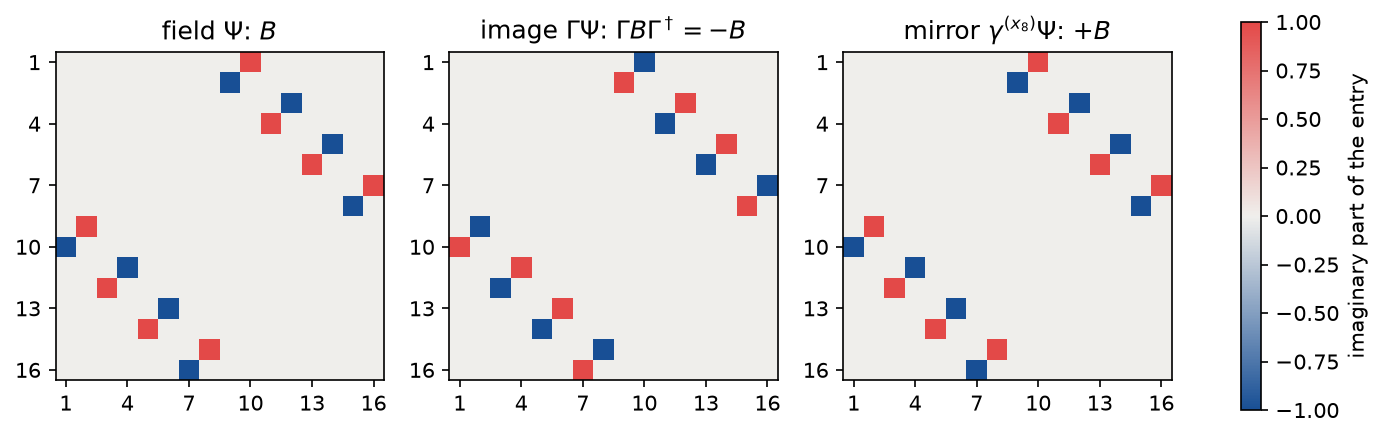

Figure 10g.1 saved as Revision/textbook/figures/10g_1_krein_metrics.png


In [3]:
image_metric = Gamma @ B @ Gamma.conj().T  # Gamma B Gamma^dagger
mirror_metric = gamma[8] @ B @ gamma[8].conj().T  # gamma8 B gamma8^dagger
signature = np.round(np.linalg.eigvalsh(image_metric)).astype(int)
report("eigenvalues -1 and +1 of Gamma B Gamma^dagger",
       f"{int(np.sum(signature == -1))} and {int(np.sum(signature == 1))}")
check_record(np.array_equal(image_metric, -B)
             and sorted(signature.tolist()) == [-1] * 8 + [1] * 8,
             "the chirality image Gamma Psi carries the Krein metric -B, (8,8)",
             record="Revision/pairing/reports/python-pairing.json, check "
                    "Q.image_krein_metric")
check_record(np.array_equal(mirror_metric, B),
             "the mirror image gamma^(x8) Psi keeps the Krein metric +B",
             record="Revision/pairing/reports/python-pairing.json, check "
                    "Q.T2_image_keeps_B")
check_record(np.array_equal(image_metric, -B) and np.array_equal(mirror_metric, B),
             "Krein signs: Gamma gives -1, gamma^(x8) gives +1",
             record="Revision/pairing/reports/wolfram-pairing.json, check "
                    "Q_Krein_metric_of_images")


def draw_matrix(ax, matrix, title):
    """Draw a real matrix as a heat map with rows and columns numbered from 1."""
    image = ax.imshow(matrix, cmap=DIVERGING, vmin=-1.0, vmax=1.0)
    size = matrix.shape[0]
    step = 3 if size <= 16 else 4  # label every third (or fourth) row and column
    ticks = list(range(0, size, step))
    ax.set_xticks(ticks, [str(t + 1) for t in ticks])
    ax.set_yticks(ticks, [str(t + 1) for t in ticks])
    ax.grid(False)  # no grid lines on top of the squares
    ax.set_title(title)
    return image


fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.2))
draw_matrix(axes[0], B.imag, "field $\\Psi$: $B$")
draw_matrix(axes[1], image_metric.imag,
            "image $\\Gamma\\Psi$: $\\Gamma B\\Gamma^\\dagger = -B$")
image = draw_matrix(axes[2], mirror_metric.imag,
                    "mirror $\\gamma^{(x_8)}\\Psi$: $+B$")
fig.colorbar(image, ax=list(axes), shrink=0.8, label="imaginary part of the entry")
save_figure(fig, "krein_metrics",
            "The Krein metrics, that is the matrices of the canonical anticommutator, "
            "carried by the field $\\Psi$ (left: $B = -iC\\gamma^{(x_4)}$), by its "
            "chirality image $\\Gamma\\Psi$ (middle: $\\Gamma B\\Gamma^\\dagger$) "
            "and by its mirror image $\\gamma^{(x_8)}\\Psi$ (right: $\\gamma^{(x_8)}"
            "B\\gamma^{(x_8)\\dagger}$), drawn as heat maps of their imaginary parts "
            "(the real parts are zero). Horizontal axis: column number, vertical "
            "axis: row number; red is $+1$, blue is $-1$, light grey is 0. The "
            "middle picture is the left one with every colour exchanged: the "
            "chirality image carries $-B$. The right picture equals the left one: "
            "the mirror image keeps $+B$.")

## 6. The Lagrangian identity and the three kernels, exactly

The next cell writes the Lagrangian $\mathcal{L}_m$ of Section 3 with SYMBOLS for the
16 components of a field and their derivatives along the eight directions, and for
the complex conjugates of all of them (sympy treats a symbol and its conjugate as
independent letters, which is exactly how the Lagrangian uses them). The function
`lagrangian(mass, M)` evaluates $\mathcal{L}_{\mathrm{mass}}$ on the field $M\chi$
for a constant matrix $M$, where $\chi$ is the column of symbols. Then the cell

- checks $\mathcal{L}_m[\Gamma\chi] + \mathcal{L}_{-m}[\chi] = 0$ for every value of
  the 16 components and their 128 derivatives (T1 for flat space, the Lagrangian
  level);
- reads off the kernel $N$ of each Lagrangian: the coefficient of
  $\chi_A^*\,\partial_4\chi_C$ is $\frac{i}{2}N_{AC}$, so $N_{AC}$ is $-2i$ times
  that coefficient;
- checks $N = B$ for $\mathcal{L}_m[\chi]$, $N = -B$ for the image Lagrangian
  $\mathcal{L}_m[\Gamma\chi]$, $N = +B$ for an independent universe
  $\mathcal{L}_{-m}[\chi]$, and the anticommutators $N^{-1} = B, -B, B$.

In [4]:
g = {a: sp.Matrix(fixture["gamma"][a - 1]) for a in range(1, 9)}  # exact gammas
C_exact = g[8] * g[1] * g[2] * g[3]
Gamma_exact = sp.diag(*[int(x) for x in diagonal])  # diag(-I8, I8), exact
B_exact = -sp.I * C_exact * g[4]
m = sp.Symbol("m", real=True)  # the mass: any real number
field = sp.Matrix(sp.symbols("c1:17"))  # chi_A, A = 1, ..., 16
field_conj = sp.Matrix(sp.symbols("cc1:17"))  # their complex conjugates chi_A^*
# d[a] and d_conj[a]: the derivatives of chi and of chi^* along x_a
d = {a: sp.Matrix(sp.symbols(f"d{a}c1:17")) for a in range(1, 9)}
d_conj = {a: sp.Matrix(sp.symbols(f"d{a}cc1:17")) for a in range(1, 9)}


def lagrangian(mass, M):
    """L_mass evaluated on the field M chi (M a constant real matrix)."""
    psi, psi_conj = M * field, M * field_conj  # M is real: (M chi)^* = M chi^*
    total = sp.Integer(0)
    for a in range(1, 9):
        kinetic = C_exact * g[a]  # the matrix C gamma^(x_a)
        dpsi, dpsi_conj = M * d[a], M * d_conj[a]
        total += sp.Rational(1, 2) * ((psi_conj.T * kinetic * dpsi)[0]
                                      - (dpsi_conj.T * kinetic * psi)[0])
    total -= mass * (psi_conj.T * C_exact * psi)[0]
    return sp.expand(total)


def kernel(expression):
    """N_AC = -2 i times the coefficient of chi_A^* d4 chi_C."""
    return sp.Matrix(16, 16, lambda A, C_: -2 * sp.I * expression.coeff(
        field_conj[A] * d[4][C_]))


L_field = lagrangian(m, sp.eye(16))  # L_m[chi]
L_image = lagrangian(m, Gamma_exact)  # L_m[Gamma chi]: the same system, new variables
L_independent = lagrangian(-m, sp.eye(16))  # L_-m[chi]: an independent universe
say(f"number of terms of L_m[chi]: {len(L_field.args)}")
identity_ok = sp.expand(L_image + L_independent) == 0
check(identity_ok, "exact: L_m[Gamma chi] = -L_-m[chi] for all components and "
                   "derivatives")
N_field, N_image, N_independent = map(kernel, (L_field, L_image, L_independent))
kernels_ok = (N_field == B_exact and N_image == -B_exact
              and N_independent == B_exact)
say(f"kernels equal to B: field {N_field == B_exact}, image {N_image == B_exact}, "
    f"independent universe {N_independent == B_exact}; image kernel = -B: "
    f"{N_image == -B_exact}")
check_record(kernels_ok,
             "kernels: N = B (field), N = -B (image), N = +B (independent universe)",
             record="Revision/pairing/reports/wolfram-pairing.json, check "
                    "Q_symplectic_kernel_grassmann")
anticommutators = [N.inv() for N in (N_field, N_image, N_independent)]
check_record(anticommutators[0] == B_exact and anticommutators[1] == -B_exact
             and anticommutators[2] == B_exact,
             "canonical rules N^(-1): {Psi,Psi^dag} = B, {chi,chi^dag} = -B, +B",
             record="Revision/pairing/reports/python-pairing.json, check "
                    "Q.image_own_quantisation")

number of terms of L_m[chi]: 272
PASS exact: L_m[Gamma chi] = -L_-m[chi] for all components and derivatives
kernels equal to B: field True, image False, independent universe True; image kernel =
    -B: True
PASS kernels: N = B (field), N = -B (image), N = +B (independent universe)
     reproduces Revision/pairing/reports/wolfram-pairing.json, check
    Q_symplectic_kernel_grassmann
PASS canonical rules N^(-1): {Psi,Psi^dag} = B, {chi,chi^dag} = -B, +B
     reproduces Revision/pairing/reports/python-pairing.json, check
    Q.image_own_quantisation


## 7. The field and its two images on a Fock space

The next cell builds the fermionic Fock space of the second notebook of this
chapter, here for any number of modes: a state is a dictionary `{pattern:
amplitude}`, a pattern is a whole number whose binary digit $p$ is the occupation of
mode $p$, `annihilate(p, state)` is $f_p$ and `create(p, state)` is $f_p^*$ (with
the sign $(-1)^{\text{(occupied modes below } p)}$ that makes different modes
anticommute). The field of one universe uses the 16 modes starting at the number
`offset`: $\Psi_A = f_{A - 1 + \mathrm{offset}}$, with the canonical conjugate
$\Psi^\dagger_A = \sum_C f^*_{C - 1 + \mathrm{offset}}B_{CA}$ (the positive
realisation, so that $\{\Psi_A, \Psi^\dagger_C\} = B_{AC}$).

For a matrix $M$ the image field is $(M\Psi)_A = \sum_D M_{AD}\Psi_D$ and its
conjugate $((M\Psi)^\dagger)_A = \sum_D \Psi^\dagger_D M^*_{AD}$. The function
`anticommutator_matrix(X, Y, state)` returns the matrix with entries
$\langle\phi|\{X_i, Y_j\}|\phi\rangle$ for a normalised state $\phi$; when the
anticommutators are numbers (as here), these entries ARE those numbers. The cell
computes it for the image $\Gamma\Psi$ and for the mirror image
$\gamma^{(x_8)}\Psi$.

In [5]:
def sign_below(n, p):
    """(-1) to the power of the number of occupied modes below mode p in pattern n."""
    return -1 if bin(n & ((1 << p) - 1)).count("1") % 2 else 1


def annihilate(p, state):
    """f_p applied to a state {pattern: amplitude}."""
    result = {}
    for n, amplitude in state.items():
        if n >> p & 1:  # mode p is occupied in the pattern n
            new = n ^ (1 << p)  # the same pattern with mode p emptied
            result[new] = result.get(new, 0) + sign_below(n, p) * amplitude
    return result


def create(p, state):
    """f_p^* (the Hilbert adjoint of f_p) applied to a state."""
    result = {}
    for n, amplitude in state.items():
        if not n >> p & 1:  # mode p is empty in the pattern n
            new = n | (1 << p)  # the same pattern with mode p filled
            result[new] = result.get(new, 0) + sign_below(n, p) * amplitude
    return result


def add(*terms):
    """The state sum of coefficient * state over the pairs (coefficient, state)."""
    result = {}
    for coefficient, state in terms:
        for n, amplitude in state.items():
            result[n] = result.get(n, 0) + coefficient * amplitude
    return result


def inner(left, right):
    """The positive inner product <left|right>."""
    return sum(np.conj(a) * right.get(n, 0) for n, a in left.items())


def largest(state):
    """The largest size of an amplitude of the state (0 for the zero state)."""
    return max((abs(a) for a in state.values()), default=0.0)


rng = np.random.default_rng(12345)  # random numbers with a fixed seed


def random_state(patterns, modes):
    """A normalised superposition of a few random patterns of the given modes."""
    state = {}
    for n in rng.integers(0, 2 ** modes, size=patterns):
        state[int(n)] = complex(rng.normal(), rng.normal())
    length = np.sqrt(inner(state, state).real)
    return {n: a / length for n, a in state.items()}


def field_op(offset):
    """The operators Psi_A (A = 1..16) of the universe whose modes start at offset."""
    return [lambda s, A=A: annihilate(A - 1 + offset, s) for A in range(1, 17)]


def conjugate_op(offset):
    """Psi^dagger_A = sum_C f^*_(C-1+offset) B_CA (the canonical conjugate)."""
    return [lambda s, A=A: add(*[(B[C_ - 1, A - 1], create(C_ - 1 + offset, s))
                                 for C_ in range(1, 17) if B[C_ - 1, A - 1] != 0])
            for A in range(1, 17)]


def mapped(M, ops):
    """The operators (M X)_A = sum_D M_AD X_D for a list X of 16 operators."""
    return [lambda s, A=A: add(*[(M[A - 1, D - 1], ops[D - 1](s))
                                 for D in range(1, 17) if M[A - 1, D - 1] != 0])
            for A in range(1, 17)]


def mapped_conjugate(M, conj_ops):
    """((M Psi)^dagger)_A = sum_D Psi^dagger_D conj(M_AD)."""
    return mapped(M.conj(), conj_ops)


def anticommutator_matrix(X, Y, state):
    """The matrix <state| {X_i, Y_j} |state> for two lists of operators."""
    result = np.zeros((len(X), len(Y)), dtype=complex)
    for i, x in enumerate(X):
        for j, y in enumerate(Y):
            both = add((1, x(y(state))), (1, y(x(state))))
            result[i, j] = inner(state, both)
    return result


Psi, Psi_dagger = field_op(0), conjugate_op(0)  # one universe: modes 0, ..., 15
phi = random_state(6, 16)
own_rule = anticommutator_matrix(Psi, Psi_dagger, phi)
image_rule = anticommutator_matrix(mapped(Gamma, Psi),
                                   mapped_conjugate(Gamma, Psi_dagger), phi)
mirror_rule = anticommutator_matrix(mapped(gamma[8], Psi),
                                    mapped_conjugate(gamma[8], Psi_dagger), phi)
errors = [np.max(np.abs(own_rule - B)), np.max(np.abs(image_rule + B)),
          np.max(np.abs(mirror_rule - B))]
report("largest deviations from B, -B and +B", ", ".join(f"{e:.1e}" for e in errors))
check(max(errors) < 1e-12,
      "Fock space: {Psi, Psi^dag} = B, image -B, mirror +B (256 entries each)")

RESULT largest deviations from B, -B and +B = 2.2e-16, 2.2e-16, 2.2e-16
PASS Fock space: {Psi, Psi^dag} = B, image -B, mirror +B (256 entries each)


## 8. One quantum system: $T \to -T$ and $J \to -J$ as operator identities

The next cell takes a mass and a plane wave with momenta along all seven slice
directions (also along the extra times) and builds, on the Fock space, four
operators of the form $X^\dagger NX = \sum_{A,C}X^\dagger_AN_{AC}X_C$:

- the energy of the field, $H_m[\Psi] = \Psi^\dagger h'_m\Psi$, and the energy that
  the mass $-m$ theory assigns to the image, $H_{-m}[\Gamma\Psi] =
  (\Gamma\Psi)^\dagger h'_{-m}(\Gamma\Psi)$;
- the charge of the field, $Q[\Psi] = \Psi^\dagger B\Psi$, and the charge the
  theory assigns to the image, $Q[\Gamma\Psi] = (\Gamma\Psi)^\dagger B(\Gamma\Psi)$.

It checks $H_m[\Psi] = -H_{-m}[\Gamma\Psi]$ and $Q[\Psi] = -Q[\Gamma\Psi]$ by
applying both sides to 150 random states, and records the expectation values for
the figure. Then it checks the quantum equation of motion of the image: with the
energy $H = H_m[\Psi]$ of the system, $[H, (\Gamma\Psi)_c] = -(h_{-m}\Gamma\Psi)_c$
with the mode Hamiltonian $h_{-m} = Bh'_{-m}$, so $i\,\partial_4(\Gamma\Psi) =
h_{-m}\Gamma\Psi$: the image obeys the wave equation of mass $-m$, moved by the
SAME energy operator.

In [6]:
m_value = 1.3  # any mass and momenta (here with momenta along the extra times too)
k = {1: 0.4, 2: -0.7, 3: 0.2, 5: 0.9, 6: -0.3, 7: 0.5, 8: 1.1}


def h_prime(mass):
    """The energy matrix h'_mass = mass C - i sum_a k_a C gamma^(x_a) of the wave."""
    return mass * C - 1j * sum(k_a * (C @ gamma[a]) for a, k_a in k.items())


def bilinear(X_dagger, N, X, state):
    """sum_(A,C) X^dagger_A N_AC X_C applied to a state."""
    terms = []
    for C_ in range(16):
        lowered = X[C_](state)
        if lowered:
            terms += [(N[A, C_], X_dagger[A](lowered)) for A in range(16)
                      if N[A, C_] != 0]
    return add(*terms)


image_field = mapped(Gamma, Psi)  # Gamma Psi
image_conjugate = mapped_conjugate(Gamma, Psi_dagger)  # (Gamma Psi)^dagger
worst_H, worst_Q, values = 0.0, 0.0, []
for _ in range(150):
    state = random_state(4, 16)
    H_field = bilinear(Psi_dagger, h_prime(m_value), Psi, state)
    H_image = bilinear(image_conjugate, h_prime(-m_value), image_field, state)
    Q_field = bilinear(Psi_dagger, B, Psi, state)
    Q_image = bilinear(image_conjugate, B, image_field, state)
    worst_H = max(worst_H, largest(add((1, H_field), (1, H_image))))
    worst_Q = max(worst_Q, largest(add((1, Q_field), (1, Q_image))))
    values.append([inner(state, X).real for X in (H_field, H_image, Q_field,
                                                   Q_image)])
values = np.array(values)  # columns: <H_m[Psi]>, <H_-m[Gamma Psi]>, <Q>, <Q image>
report("largest |(H_m[Psi] + H_-m[Gamma Psi]) phi| over 150 states", f"{worst_H:.1e}")
report("largest |(Q[Psi] + Q[Gamma Psi]) phi| over 150 states", f"{worst_Q:.1e}")
check_record(worst_H < 1e-12 and worst_Q < 1e-12,
             "operators: H_m[Psi] = -H_-m[Gamma Psi] and Q[Psi] = -Q[Gamma Psi]",
             record="Revision/pairing/reports/wolfram-pairing.json, check "
                    "Q_generators_of_the_image_grassmann")

h_mode_minus = B @ h_prime(-m_value)  # the mode Hamiltonian of mass -m
worst = 0.0
for c_ in range(16):
    H_after = bilinear(Psi_dagger, h_prime(m_value), Psi, image_field[c_](phi))
    H_before = image_field[c_](bilinear(Psi_dagger, h_prime(m_value), Psi, phi))
    commutator = add((1, H_after), (-1, H_before))  # [H, (Gamma Psi)_c] phi
    expected = add(*[(-h_mode_minus[c_, d_], image_field[d_](phi))
                     for d_ in range(16)])
    worst = max(worst, largest(add((1, commutator), (-1, expected))))
report("largest violation of [H, (Gamma Psi)_c] = -(h_-m Gamma Psi)_c", f"{worst:.1e}")
check(worst < 1e-12, "the image obeys i d4 (Gamma Psi) = h_-m Gamma Psi under the "
                     "same H")

RESULT largest |(H_m[Psi] + H_-m[Gamma Psi]) phi| over 150 states = 0.0e+00
RESULT largest |(Q[Psi] + Q[Gamma Psi]) phi| over 150 states = 0.0e+00
PASS operators: H_m[Psi] = -H_-m[Gamma Psi] and Q[Psi] = -Q[Gamma Psi]
     reproduces Revision/pairing/reports/wolfram-pairing.json, check
    Q_generators_of_the_image_grassmann
RESULT largest violation of [H, (Gamma Psi)_c] = -(h_-m Gamma Psi)_c = 1.6e-17
PASS the image obeys i d4 (Gamma Psi) = h_-m Gamma Psi under the same H


The Revision record states the same fact for the one-particle generators, exactly
and for all momenta: a field of mass $-m$ moves with the generator $Bh'_{-m}$; its
image under $\Gamma$ carries the metric $-B$ and the energy matrix $-h'_m$, and the
two signs compensate, $(-B)(-h'_m) = \Gamma(Bh'_{-m})\Gamma = Bh'_m$. The next cell
checks this with sympy for symbolic $m$ and $k_1, \dots, k_8$, together with
$\Gamma h'_m\Gamma = -h'_{-m}$, and then draws the expectation values of the
previous cell.

PASS exact: (-B)(-h'_m) = Gamma (B h'_-m) Gamma = B h'_m; Gamma h'_m Gamma = -h'_-m
     reproduces Revision/pairing/reports/python-pairing.json, check
    Q.image_generators_same_dynamics


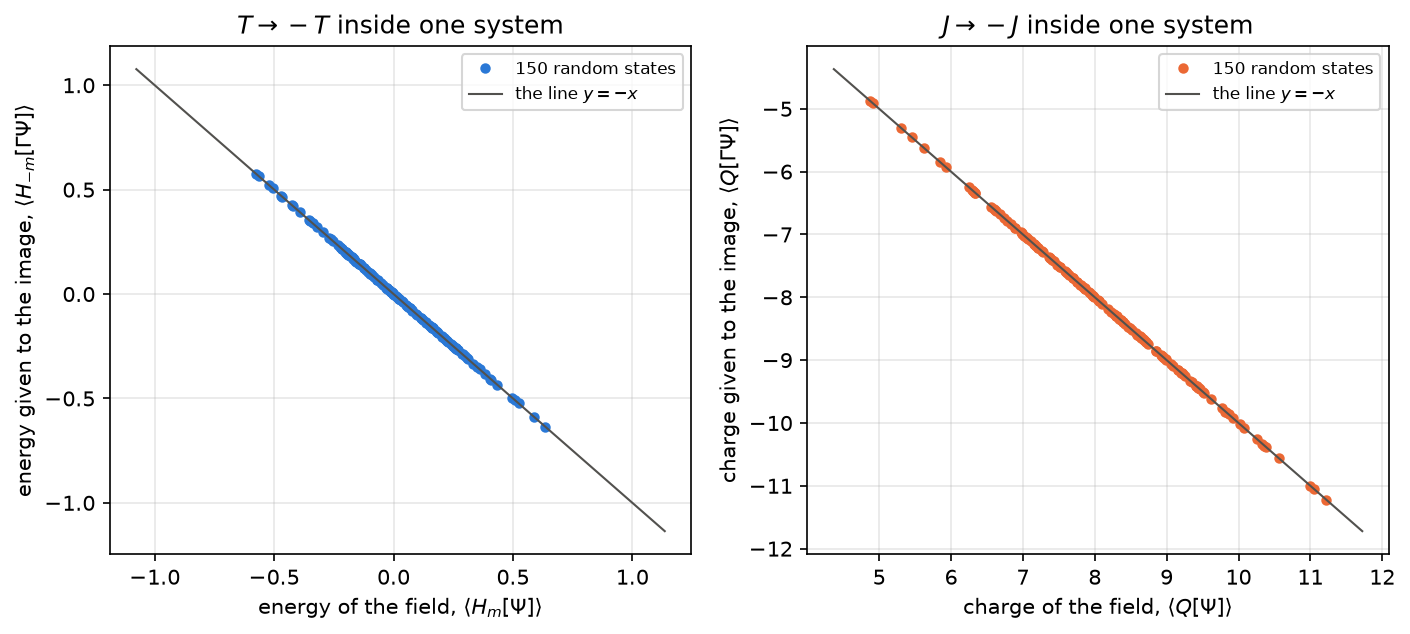

Figure 10g.2 saved as Revision/textbook/figures/10g_2_one_system.png


In [7]:
k_symbol = {a: sp.Symbol(f"k{a}", real=True) for a in (1, 2, 3, 5, 6, 7, 8)}


def h_prime_exact(mass):
    """The exact energy matrix mass C - i sum_a k_a C gamma^(x_a)."""
    result = mass * C_exact
    for a, k_a in k_symbol.items():
        result = result - sp.I * k_a * C_exact * g[a]
    return result


zero = sp.zeros(16, 16)
own_data = (-B_exact) * (-h_prime_exact(m))  # the image: metric -B, energy -h'_m
by_map = Gamma_exact * (B_exact * h_prime_exact(-m)) * Gamma_exact
same = ((own_data - by_map).applyfunc(sp.expand) == zero
        and (own_data - B_exact * h_prime_exact(m)).applyfunc(sp.expand) == zero)
energy_rule = (Gamma_exact * h_prime_exact(m) * Gamma_exact
               + h_prime_exact(-m)).applyfunc(sp.expand) == zero
check_record(same and energy_rule,
             "exact: (-B)(-h'_m) = Gamma (B h'_-m) Gamma = B h'_m; "
             "Gamma h'_m Gamma = -h'_-m",
             record="Revision/pairing/reports/python-pairing.json, check "
                    "Q.image_generators_same_dynamics")

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))
panels = ((axes[0], 0, 1, BLUE, "energy",
           "$\\langle H_m[\\Psi]\\rangle$", "$\\langle H_{-m}[\\Gamma\\Psi]\\rangle$"),
          (axes[1], 2, 3, ORANGE, "charge",
           "$\\langle Q[\\Psi]\\rangle$", "$\\langle Q[\\Gamma\\Psi]\\rangle$"))
for ax, x_col, y_col, colour, what, x_label, y_label in panels:
    ax.plot(values[:, x_col], values[:, y_col], "o", color=colour, markersize=4,
            label="150 random states")
    low, high = values[:, x_col].min() - 0.5, values[:, x_col].max() + 0.5
    ax.plot([low, high], [-low, -high], color=GREY, linewidth=1,
            label="the line $y = -x$")
    ax.set_xlabel(f"{what} of the field, {x_label}")
    ax.set_ylabel(f"{what} given to the image, {y_label}")
    ax.legend(fontsize=8)
axes[0].set_title("$T \\to -T$ inside one system")
axes[1].set_title("$J \\to -J$ inside one system")
save_figure(fig, "one_system",
            "For 150 random states of the Fock space of one field: left, the "
            "expectation value of the energy $H_m(\\Psi) = \\Psi^\\dagger h'_m\\Psi$ "
            "of the field (horizontal axis) against the expectation value of the "
            "energy $H_{-m}(\\Gamma\\Psi)$ that the mass $-m$ theory assigns to the "
            "chirality image (vertical axis), for $m = 1.3$ and a plane wave with "
            "momenta along all seven slice directions; right, the same for the "
            "charges $Q = \\Psi^\\dagger B\\Psi$ and $Q(\\Gamma\\Psi)$. Axes in the "
            "units of $m$ (left) and pure numbers (right). Every point lies on the "
            "grey line $y = -x$: the reversal of the energy and of the charge "
            "under T1 is an identity between operators of ONE quantum system, not "
            "a statement about a second universe.")

## 9. Which images could be an independent universe?

An independently quantised universe of mass $-m$ would be a field $\Psi_2$ with
$\{\Psi_2, \Psi_2^\dagger\} = +B$ (its own Lagrangian, Section 6) that
anticommutes with the first field: $\{\Psi_{2A}, \Psi_C^\dagger\} = 0$ and
$\{\Psi_{2A}, \Psi_C\} = 0$. The next cell tests three candidates built from the
first field $\Psi$:

- the chirality image $\Gamma\Psi$ (T1);
- the mirror image $\gamma^{(x_8)}\Psi$ (T2, here without the reflection of the
  hidden coordinate, which does not change the anticommutators at one point);
- the conjugate field $\Psi^c = \Gamma\Psi^{\dagger T}$, that is
  $\Psi^c_A = \sum_D\Gamma_{AD}\Psi^\dagger_D$, the conjugation of the quantised
  field that keeps the canonical rule (it reverses the mass; second notebook of
  this chapter).

For each it computes, on the Fock space, its own anticommutator matrix and the two
cross matrices with the first field, and their ranks. Independence would need both
cross matrices to be 0.

In [8]:
conjugate_field = mapped(Gamma, Psi_dagger)  # Psi^c_A = sum_D Gamma_AD Psi^dag_D
# Its canonical conjugate: (Psi^c)^dagger_A = sum_D conj(Gamma_AD) Psi_D, by the
# rule (Psi^dagger)^dagger = Psi of the canonical relations (Gamma is real).
conjugate_field_dagger = mapped(Gamma, Psi)
candidates = {
    "Gamma Psi": (image_field, image_conjugate),
    "gamma8 Psi": (mapped(gamma[8], Psi), mapped_conjugate(gamma[8], Psi_dagger)),
    "Psi^c = Gamma Psi^dag T": (conjugate_field, conjugate_field_dagger),
}
phi = random_state(6, 16)
results = {}
for label, (X, X_dagger) in candidates.items():
    metric = anticommutator_matrix(X, X_dagger, phi)  # {X_A, X_C^dagger}
    cross_1 = anticommutator_matrix(X, Psi_dagger, phi)  # {X_A, Psi^dagger_C}
    cross_2 = anticommutator_matrix(X, Psi, phi)  # {X_A, Psi_C}
    sign = (1 if np.allclose(metric, B) else -1 if np.allclose(metric, -B) else 0)
    ranks = (np.linalg.matrix_rank(cross_1), np.linalg.matrix_rank(cross_2))
    results[label] = (sign, ranks, cross_1, cross_2)
    say(f"{label:24s} metric {sign:+d} B; rank of {{X, Psi^dag}} = {ranks[0]:2d}, "
        f"rank of {{X, Psi}} = {ranks[1]:2d}")
chirality = results["Gamma Psi"]
conjugate = results["Psi^c = Gamma Psi^dag T"]
check_record(chirality[0] == -1 and chirality[1] == (16, 0)
             and np.allclose(chirality[2], Gamma @ B),
             "Gamma Psi: metric -B and {Gamma Psi, Psi^dag} = Gamma B of rank 16",
             record="Revision/pairing/reports/wolfram-pairing.json, check "
                    "Q_no_identification_of_independent_universes")
check_record(conjugate[0] == 1 and conjugate[1] == (0, 16)
             and np.allclose(conjugate[3], -Gamma @ B),
             "Psi^c keeps +B (Gamma B^T Gamma^dag = B) but {Psi^c, Psi} = -Gamma B",
             record="Revision/lead_checks/reports/charge-conjugation-and-u1.json, "
                    "check quantum_charge_conjugation_unitary_type")
check(results["gamma8 Psi"][0] == 1 and results["gamma8 Psi"][1] == (16, 0),
      "gamma8 Psi keeps +B; as an operator of the same field it is not independent")

Gamma Psi                metric -1 B; rank of {X, Psi^dag} = 16, rank of {X, Psi} =  0
gamma8 Psi               metric +1 B; rank of {X, Psi^dag} = 16, rank of {X, Psi} =  0
Psi^c = Gamma Psi^dag T  metric +1 B; rank of {X, Psi^dag} =  0, rank of {X, Psi} = 16
PASS Gamma Psi: metric -B and {Gamma Psi, Psi^dag} = Gamma B of rank 16
     reproduces Revision/pairing/reports/wolfram-pairing.json, check
    Q_no_identification_of_independent_universes
PASS Psi^c keeps +B (Gamma B^T Gamma^dag = B) but {Psi^c, Psi} = -Gamma B
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    quantum_charge_conjugation_unitary_type
PASS gamma8 Psi keeps +B; as an operator of the same field it is not independent


The result in words. The chirality image has the wrong canonical rule ($-B$
instead of $+B$) AND does not anticommute with the first field (rank 16): it is the
first universe in other variables. The mirror image and the conjugate field have
the right rule $+B$, but they too are built from the operators of the first field
and do not anticommute with it. The rule $+B$ of the mirror image matches the rule
of an independently quantised mirror universe, so such a universe can be quantised
as an ordinary copy (statement Q5 of the record); for the chirality image this is
impossible (statement Q3). A second universe must therefore be a NEW field on a
larger state space, which the next section builds.

## 10. Two independently quantised universes

The next cell puts universe 1 (mass $+m$) on the modes 0 to 15 and universe 2 (mass
$-m$) on the modes 16 to 31 of one Fock space, each with its own canonical
conjugate. It computes the $32 \times 32$ anticommutator matrix of the combined
list $(\Psi_1, \Psi_2)$ with $(\Psi_1^\dagger, \Psi_2^\dagger)$, which must be
$\mathrm{diag}(B, B)$, and, for comparison, that of the list $(\Psi_1,
\Gamma\Psi_1)$ with its conjugates, which must be the block matrix with $B$,
$B\Gamma$, $\Gamma B$ and $-B$. Then it draws both.

RESULT largest |{Psi_1, Psi_2}| (must be 0) = 0.0e+00
PASS two universes: diag(B, B); field and image: blocks B, B Gamma, Gamma B, -B


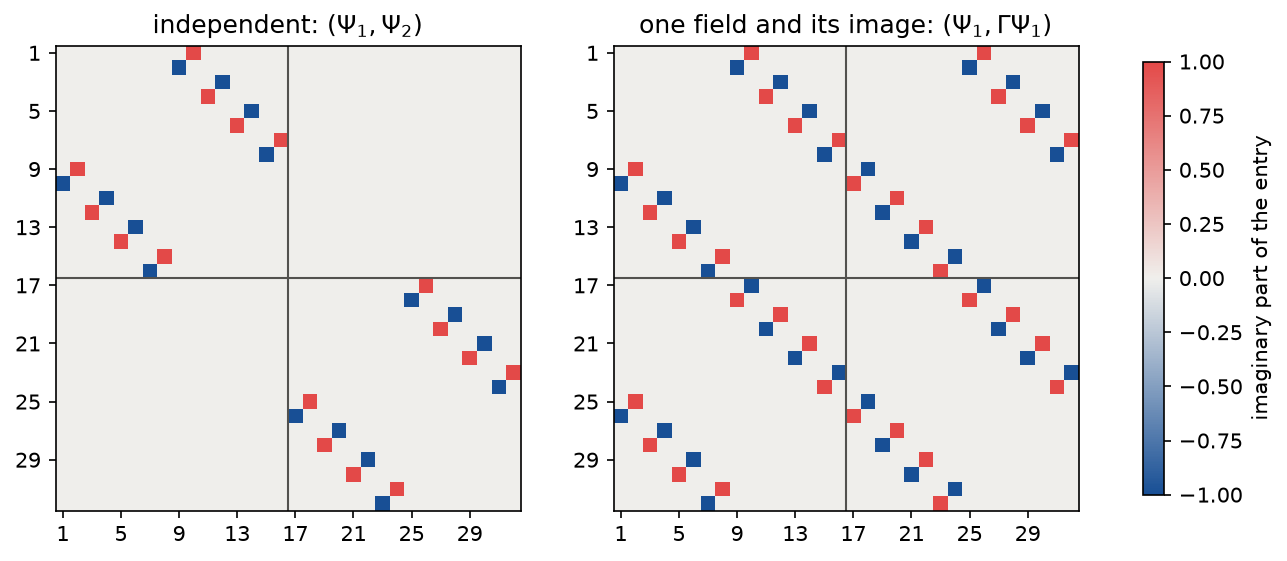

Figure 10g.3 saved as Revision/textbook/figures/10g_3_anticommutator_blocks.png


In [9]:
Psi_1, Psi_1_dagger = field_op(0), conjugate_op(0)  # universe 1: modes 0..15
Psi_2, Psi_2_dagger = field_op(16), conjugate_op(16)  # universe 2: modes 16..31
phi_32 = random_state(6, 32)
two_universes = anticommutator_matrix(Psi_1 + Psi_2, Psi_1_dagger + Psi_2_dagger,
                                      phi_32)
image_pair = anticommutator_matrix(
    Psi_1 + mapped(Gamma, Psi_1),
    Psi_1_dagger + mapped_conjugate(Gamma, Psi_1_dagger), phi_32)
zero_16 = np.zeros((16, 16))
expected_two = np.block([[B, zero_16], [zero_16, B]])
expected_image = np.block([[B, B @ Gamma], [Gamma @ B, -B]])
cross_zero = np.max(np.abs(anticommutator_matrix(Psi_1, Psi_2, phi_32)))
report("largest |{Psi_1, Psi_2}| (must be 0)", f"{cross_zero:.1e}")
check(np.allclose(two_universes, expected_two) and cross_zero < 1e-12
      and np.allclose(image_pair, expected_image),
      "two universes: diag(B, B); field and image: blocks B, B Gamma, Gamma B, -B")

fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.0))
draw_matrix(axes[0], two_universes.imag,
            "independent: $(\\Psi_1, \\Psi_2)$")
image = draw_matrix(axes[1], image_pair.imag,
                    "one field and its image: $(\\Psi_1, \\Gamma\\Psi_1)$")
for ax in axes:
    ax.axhline(15.5, color=GREY, linewidth=1)  # the border between the two halves
    ax.axvline(15.5, color=GREY, linewidth=1)
fig.colorbar(image, ax=list(axes), shrink=0.75, label="imaginary part of the entry")
save_figure(fig, "anticommutator_blocks",
            "The $32 \\times 32$ anticommutator matrices computed on the Fock space "
            "of 32 fermion modes (imaginary parts; the real parts are zero; red "
            "$+1$, blue $-1$, light grey 0; horizontal axis: column, vertical axis: "
            "row; grey lines separate the two halves). Left: two independently "
            "quantised universes $\\Psi_1$ (mass $+m$) and $\\Psi_2$ (mass $-m$): "
            "the diagonal blocks are both $+B$ and the off-diagonal blocks are "
            "empty, the universes anticommute. Right: a field and its chirality "
            "image $\\Gamma\\Psi_1$: the lower right block is $-B$ and the "
            "off-diagonal blocks $B\\Gamma$ and $\\Gamma B$ are full, so the image "
            "is not a second universe but the same one.")

## 11. The generators add: no cancellation

The one-particle generator of the two independent universes is the block matrix
$\mathrm{diag}(Bh'_m, Bh'_{-m})$. The next cell computes its exact eigenvalues
with sympy at zero momentum (the record's case: $+m$ and $-m$, 16 times each), and
then, with numbers, its eigenvalues for $m$ from $-3$ to $3$ at zero momentum and
at the good-sector momentum $k_1 = 1.5$. In the second case they are
$\pm\sqrt{m^2 + k_1^2}$ (16 each); in no case is an eigenvalue 0 for $m \neq 0$, so
the total generator is not zero: the two universes do not cancel each other.

exact eigenvalues of diag(B h'_m, B h'_-m) at k = 0: +m 16 times, -m 16 times, 2
    different values
PASS block generator at k = 0: eigenvalues +m and -m, 16 each, none zero
     reproduces Revision/pairing/reports/python-pairing.json, check
    Q.no_cancellation_independent_universes
RESULT largest deviation from +-sqrt(m^2 + k1^2), 16 each = 4.9e-15
PASS with k1 = 1.5 the 32 eigenvalues are +-sqrt(m^2 + k1^2): never 0


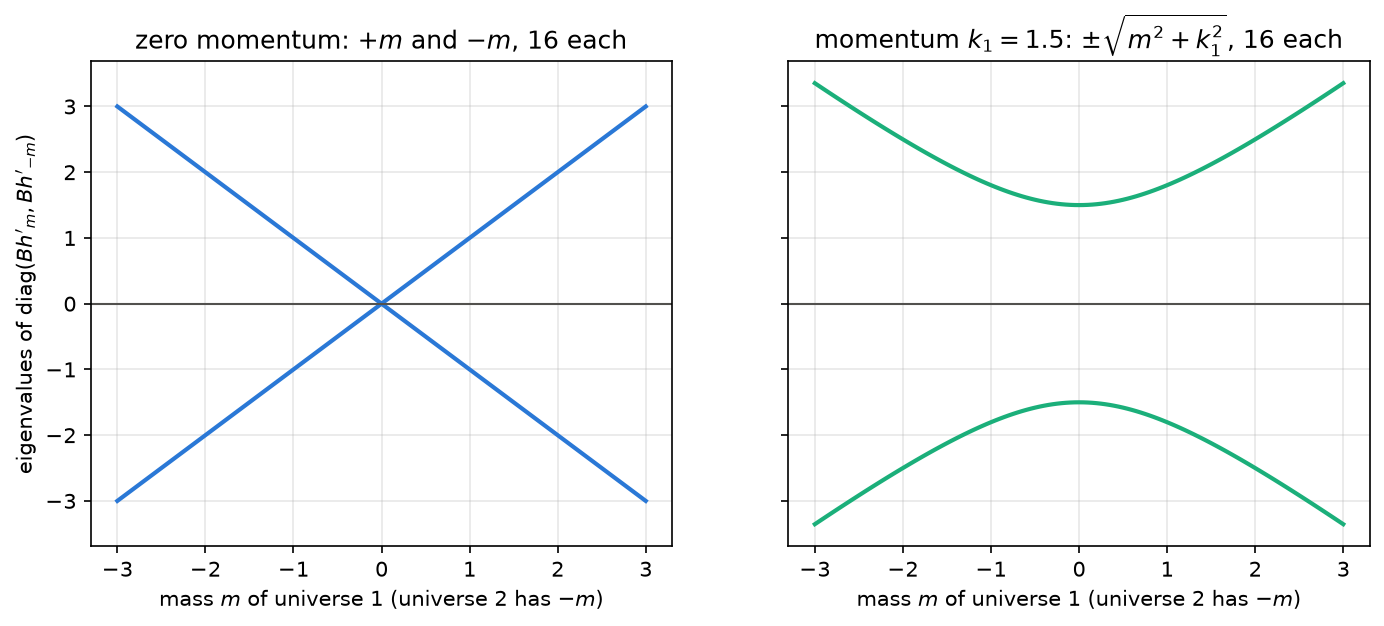

Figure 10g.4 saved as Revision/textbook/figures/10g_4_block_generator.png


In [10]:
zero_momentum = {k_a: 0 for k_a in k_symbol.values()}
block = sp.diag((B_exact * h_prime_exact(m)).subs(zero_momentum),
                (B_exact * h_prime_exact(-m)).subs(zero_momentum))
block_eigenvalues = block.eigenvals()  # {eigenvalue: how often}
say(f"exact eigenvalues of diag(B h'_m, B h'_-m) at k = 0: +m "
    f"{block_eigenvalues.get(m, 0)} times, -m {block_eigenvalues.get(-m, 0)} times, "
    f"{len(block_eigenvalues)} different values")
check_record(block_eigenvalues == {m: 16, -m: 16},
             "block generator at k = 0: eigenvalues +m and -m, 16 each, none zero",
             record="Revision/pairing/reports/python-pairing.json, check "
                    "Q.no_cancellation_independent_universes")


def block_numbers(mass, k1):
    """The 32 eigenvalues of diag(B h'_mass, B h'_-mass) with momentum k1 along x1."""
    def energy(mu):  # the energy matrix of mass mu and momentum k1
        return mu * C - 1j * k1 * (C @ gamma[1])
    top, bottom = B @ energy(mass), B @ energy(-mass)
    values = np.concatenate([np.linalg.eigvals(top), np.linalg.eigvals(bottom)])
    return np.sort(values.real)


masses = np.linspace(-3.0, 3.0, 121)
spectra_0 = np.array([block_numbers(x, 0.0) for x in masses])
spectra_k = np.array([block_numbers(x, 1.5) for x in masses])
formula_k = np.sqrt(masses ** 2 + 1.5 ** 2)
error_k = max(np.max(np.abs(spectra_k[:, 16:] - formula_k[:, None])),
              np.max(np.abs(spectra_k[:, :16] + formula_k[:, None])))
report("largest deviation from +-sqrt(m^2 + k1^2), 16 each", f"{error_k:.1e}")
check(error_k < 1e-10 and np.min(np.abs(spectra_k)) >= 1.5 - 1e-10,
      "with k1 = 1.5 the 32 eigenvalues are +-sqrt(m^2 + k1^2): never 0")

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), sharey=True)
axes[0].plot(masses, spectra_0[:, [0, 31]], color=BLUE, linewidth=2)
axes[0].set_title("zero momentum: $+m$ and $-m$, 16 each")
axes[1].plot(masses, spectra_k[:, [0, 31]], color=GREEN, linewidth=2)
axes[1].set_title("momentum $k_1 = 1.5$: $\\pm\\sqrt{m^2 + k_1^2}$, 16 each")
for ax in axes:
    ax.axhline(0.0, color=GREY, linewidth=1)
    ax.set_xlabel("mass $m$ of universe 1 (universe 2 has $-m$)")
axes[0].set_ylabel("eigenvalues of diag$(Bh'_m, Bh'_{-m})$")
save_figure(fig, "block_generator",
            "The 32 eigenvalues (vertical axes, units of the momentum and mass) of "
            "the one-particle generator $\\mathrm{diag}(Bh'_m, Bh'_{-m})$ of two "
            "independently quantised universes of masses $+m$ and $-m$, against "
            "$m$ from $-3$ to $3$ (horizontal axes); each line carries 16 "
            "eigenvalues. Left: zero momentum, eigenvalues $+m$ and $-m$, which "
            "vanish only at $m = 0$. Right: the momentum $k_1 = 1.5$, eigenvalues "
            "$\\pm\\sqrt{m^2 + k_1^2}$, never 0. The generators of the two universes "
            "add; nothing in them cancels.")

## 12. One good-sector momentum in both universes

The last computation repeats, for the two universes together, the positive Fock
construction of the third notebook of this chapter, for the recorded good-sector
momentum $m = 2$, $k = (1, 2, 0, 4)$ along $(x_1, x_2, x_3, x_8)$, $E = 5$.
Universe 1 uses the orthonormal eigenvectors $u_s$ ($+E$) and $v_s$ ($-E$) of $h_m$;
universe 2 uses $\Gamma u_s$ and $\Gamma v_s$, which are eigenvectors of $h_{-m} =
\Gamma h_m\Gamma$ with the same eigenvalues. In each universe modes 0 to 7 of its
half are particles and modes 8 to 15 antiparticles (created by $d^*$, so
$\Psi = \sum_s(u_sb_s + v_sd_s^*)$ and $\Psi^\dagger = \chi B$, with $\chi$ the
Hilbert adjoint). The cell checks the canonical rule in both universes, the vacuum
energy $-8E$ of each, that every pattern is an energy and charge eigenstate with
the normal-ordered total energy $E \times$(number of quanta) and the total charge
(particles minus antiparticles), on 200 random patterns, and the pair state
"particle in universe 1, antiparticle in universe 2". Energy and charge are applied
in the mode form $\chi N\Psi = \sum_{p,q}(W^\dagger NW)_{pq}F_p^*F_q$, where $F_p$
is $b$ or $d^*$ (the same operator as $\sum_{A,C}\chi_AN_{AC}\Psi_C$, but much
faster to apply, because $W^\dagger hW$ is diagonal).

In [11]:
def orthonormal_columns(P):
    """Orthonormal columns that span the range of P (Gram-Schmidt, done twice)."""
    basis = []
    for column in P.T:
        v = column.astype(complex)
        for _ in range(2):  # the second pass removes rounding errors
            for e in basis:
                v = v - (e.conj() @ v) * e
        length = np.sqrt((v.conj() @ v).real)
        if length > 1e-8:
            basis.append(v / length)
    return np.array(basis).T


def mode_hamiltonian(mass, momenta):
    """h = -i mass gamma^(x4) - gamma^(x4) sum_a k_a gamma^(x_a)."""
    h = -1j * mass * gamma[4]
    for a, k_a in momenta.items():
        h = h - k_a * (gamma[4] @ gamma[a])
    return h


sample = {1: 1, 2: 2, 8: 4}  # the recorded good-sector momentum, with m = 2
h_plus, h_minus = mode_hamiltonian(2, sample), mode_hamiltonian(-2, sample)
E = 5.0  # sqrt(4 + 1 + 4 + 16)
W1 = np.hstack([orthonormal_columns((I16 + h_plus / E) / 2),
                orthonormal_columns((I16 - h_plus / E) / 2)])  # u_1..u_8, v_1..v_8
W2 = Gamma @ W1  # the eigenvectors of h_-m = Gamma h_m Gamma
check(np.allclose(h_minus @ W2[:, :8], E * W2[:, :8])
      and np.allclose(h_minus @ W2[:, 8:], -E * W2[:, 8:])
      and np.allclose(W2.conj().T @ W2, I16),
      "Gamma u_s and Gamma v_s are orthonormal eigenvectors of h_-m, energies +-E")


def universe(W, offset):
    """Psi, chi (Hilbert adjoint), Psi^dagger = chi B and the mode operators of
    one universe whose 16 modes start at offset."""
    def F(p, s):  # b (particle modes p < 8) or d^* (antiparticle modes p >= 8)
        return annihilate(p + offset, s) if p < 8 else create(p + offset, s)

    def F_star(p, s):  # the Hilbert adjoint of F_p
        return create(p + offset, s) if p < 8 else annihilate(p + offset, s)

    psi = [lambda s, A=A: add(*[(W[A, p], F(p, s)) for p in range(16)])
           for A in range(16)]  # Psi_A = sum_p W_Ap F_p
    chi = [lambda s, A=A: add(*[(np.conj(W[A, p]), F_star(p, s)) for p in range(16)])
           for A in range(16)]  # chi_A = sum_p conj(W_Ap) F_p^*
    psi_dagger = mapped(B.T, chi)  # Psi^dagger_A = sum_C chi_C B_CA
    return psi, chi, psi_dagger, F, F_star


def mode_bilinear(W, F, F_star, N, state):
    """chi N Psi = sum_(p,q) (W^dagger N W)_pq F_p^* F_q applied to a state (the
    same operator as sum_(A,C) chi_A N_AC Psi_C, written with the mode operators)."""
    M = W.conj().T @ N @ W
    terms = []
    for q in range(16):
        lowered = F(q, state)
        if lowered:
            terms += [(M[p, q], F_star(p, lowered)) for p in range(16)
                      if abs(M[p, q]) > 1e-12]
    return add(*terms)


psi_1, chi_1, psi_1_dagger, F_1, F_1_star = universe(W1, 0)
psi_2, chi_2, psi_2_dagger, F_2, F_2_star = universe(W2, 16)
phi_32 = random_state(4, 32)
rule_1 = anticommutator_matrix(psi_1, psi_1_dagger, phi_32)
rule_2 = anticommutator_matrix(psi_2, psi_2_dagger, phi_32)
rule_12 = anticommutator_matrix(psi_1, psi_2_dagger, phi_32)
check(np.allclose(rule_1, B) and np.allclose(rule_2, B) and np.allclose(rule_12, 0),
      "positive realisation: {Psi_1, Psi_1^dag} = {Psi_2, Psi_2^dag} = B, cross 0")


def total_energy(state):
    """(H_1 + H_2) state, with H = chi h Psi in each universe."""
    return add((1, mode_bilinear(W1, F_1, F_1_star, h_plus, state)),
               (1, mode_bilinear(W2, F_2, F_2_star, h_minus, state)))


def total_charge(state):
    """(Q_1 + Q_2) state, with Q = Psi^dagger B Psi = chi Psi in each universe."""
    return add((1, mode_bilinear(W1, F_1, F_1_star, I16, state)),
               (1, mode_bilinear(W2, F_2, F_2_star, I16, state)))


VACUUM = {0: 1.0}
vacuum_energy = inner(VACUUM, total_energy(VACUUM)).real
vacuum_charge = inner(VACUUM, total_charge(VACUUM)).real
report("vacuum energy and charge of the two universes",
       f"{vacuum_energy:.10f} and {vacuum_charge:.10f}")
check_record(abs(vacuum_energy + 16 * E) < 1e-9 and abs(vacuum_charge - 16) < 1e-9,
             "each universe has the sea energy -8E = -40 (total -80) and charge 8",
             record="Revision/theory/reports/python-field-theory.json, check "
                    "good_sector_positive_fock_realisation")

PASS Gamma u_s and Gamma v_s are orthonormal eigenvectors of h_-m, energies +-E
PASS positive realisation: {Psi_1, Psi_1^dag} = {Psi_2, Psi_2^dag} = B, cross 0
RESULT vacuum energy and charge of the two universes = -80.0000000000 and 16.0000000000
PASS each universe has the sea energy -8E = -40 (total -80) and charge 8
     reproduces Revision/theory/reports/python-field-theory.json, check
    good_sector_positive_fock_realisation


The next cell checks the eigenvalue statement on 200 random patterns, computes the
pair state $b^*_{1}d^*_{2}|0\rangle$ (a particle in universe 1 and an antiparticle
in universe 2), counts all $2^{32}$ patterns by the number of quanta and the total
charge with the binomial numbers $\binom{8}{j}$ (four groups of 8 modes: particles
and antiparticles of each universe), and draws the counts.

PASS 200 random patterns: energy E (quanta) - 16E, charge (b - d) + 16
RESULT pair state: normal-ordered total energy and total charge = 10.0000000000 and
    0.0000000000
PASS a particle in universe 1 and an antiparticle in universe 2: charge 0, energy 2E
RESULT number of patterns = 4294967296
RESULT patterns of zero normal-ordered energy = 1
RESULT fewest quanta of a non-vacuum state of total charge 0 = 2
PASS only the vacuum has energy 0; charge 0 needs at least 2 quanta (energy 2E)


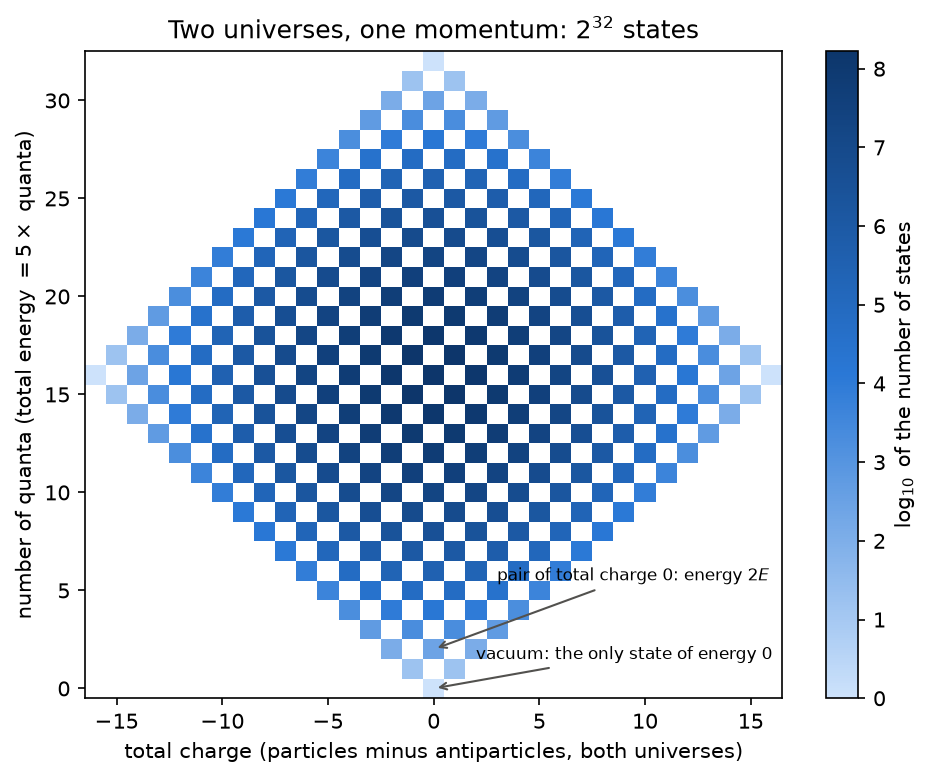

Figure 10g.5 saved as Revision/textbook/figures/10g_5_two_universe_states.png


In [12]:
def quanta_and_charge(n):
    """(number of quanta, total charge) of the pattern n of the 32 modes."""
    groups = [bin((n >> shift) & 0xFF).count("1") for shift in (0, 8, 16, 24)]
    b_1, d_1, b_2, d_2 = groups  # particles and antiparticles of each universe
    return b_1 + d_1 + b_2 + d_2, b_1 - d_1 + b_2 - d_2


eigen_ok = True
for n in rng.integers(0, 2 ** 32, size=200):
    n = int(n)
    quanta, charge = quanta_and_charge(n)
    state = {n: 1.0}
    eigen_ok = eigen_ok and largest(add(
        (1, total_energy(state)), (-(E * quanta + vacuum_energy), state))) < 1e-9
    eigen_ok = eigen_ok and largest(add(
        (1, total_charge(state)), (-(charge + vacuum_charge), state))) < 1e-9
check(eigen_ok, "200 random patterns: energy E (quanta) - 16E, charge (b - d) + 16")

pair = create(24, create(0, VACUUM))  # b_1^* (mode 0), then d_2^* (mode 24)
pair_energy = inner(pair, total_energy(pair)).real - vacuum_energy
pair_charge = inner(pair, total_charge(pair)).real - vacuum_charge
report("pair state: normal-ordered total energy and total charge",
       f"{pair_energy:.10f} and {pair_charge:.10f}")
check(abs(pair_energy - 2 * E) < 1e-9 and abs(pair_charge) < 1e-9,
      "a particle in universe 1 and an antiparticle in universe 2: charge 0, "
      "energy 2E")

counts = np.zeros((33, 33), dtype=np.int64)  # rows: quanta, columns: charge + 16
for b_1 in range(9):
    for d_1 in range(9):
        for b_2 in range(9):
            for d_2 in range(9):
                number = comb(8, b_1) * comb(8, d_1) * comb(8, b_2) * comb(8, d_2)
                counts[b_1 + d_1 + b_2 + d_2, b_1 - d_1 + b_2 - d_2 + 16] += number
zero_energy_states = int(counts[0].sum())
zero_charge_lowest = min(q for q in range(33) if q > 0 and counts[q, 16] > 0)
report("number of patterns", int(counts.sum()))
report("patterns of zero normal-ordered energy", zero_energy_states)
report("fewest quanta of a non-vacuum state of total charge 0", zero_charge_lowest)
check(counts.sum() == 2 ** 32 and zero_energy_states == 1 and zero_charge_lowest == 2,
      "only the vacuum has energy 0; charge 0 needs at least 2 quanta (energy 2E)")

fig, ax = plt.subplots(figsize=(7.5, 5.6))
shown = np.where(counts > 0, np.log10(np.maximum(counts, 1)), np.nan)  # NaN: empty
light_to_dark = LinearSegmentedColormap.from_list(
    "light_to_dark_blue", ["#cde2fb", "#2a78d6", "#0d366b"])
image = ax.imshow(shown, origin="lower", cmap=light_to_dark, aspect="auto",
                  extent=(-16.5, 16.5, -0.5, 32.5))
ax.annotate("vacuum: the only state of energy 0", (0, 0), xytext=(2.0, 1.5),
            fontsize=8, arrowprops={"arrowstyle": "->", "color": GREY})
ax.annotate("pair of total charge 0: energy $2E$", (0, 2), xytext=(3.0, 5.5),
            fontsize=8, arrowprops={"arrowstyle": "->", "color": GREY})
ax.set_xlabel("total charge (particles minus antiparticles, both universes)")
ax.set_ylabel("number of quanta (total energy $= 5 \\times$ quanta)")
ax.set_title("Two universes, one momentum: $2^{32}$ states")
ax.grid(False)
fig.colorbar(image, ax=ax, label="$\\log_{10}$ of the number of states")
save_figure(fig, "two_universe_states",
            "All $2^{32}$ quantum states of two independently quantised universes "
            "of masses $+m$ and $-m$ for one good-sector momentum ($m = 2$, $k = (1, "
            "2, 0, 4)$, $E = 5$ in both), sorted by the total charge (horizontal "
            "axis) and the number of quanta (vertical axis; the normal-ordered total "
            "energy is $5$ times the number of quanta). The colour is the base-10 "
            "logarithm of the number of states in each square; white squares are "
            "empty. The energies of the two universes add: only the vacuum has "
            "total energy 0, every other state has a positive energy, and a pair of "
            "total charge 0 (a particle in one universe, an antiparticle in the "
            "other) has the energy $2E$, not 0.")

## 13. The last check

The last cell checks that all five figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [13]:
for name in ("10g_1_krein_metrics.png", "10g_2_one_system.png",
             "10g_3_anticommutator_blocks.png", "10g_4_block_generator.png",
             "10g_5_two_universe_states.png"):
    check(output_file(f"{FIGURE_FOLDER}/{name}").is_file(),
          f"the figure file {name} exists")
all_checks_passed()

PASS the figure file 10g_1_krein_metrics.png exists
PASS the figure file 10g_2_one_system.png exists
PASS the figure file 10g_3_anticommutator_blocks.png exists
PASS the figure file 10g_4_block_generator.png exists
PASS the figure file 10g_5_two_universe_states.png exists
ALL 30 CHECKS PASSED (notebook 10g)


## 14. What this notebook showed

- PROVED (exactly, for all field values, flat 4+4 space, $U = 0$):
  $\mathcal{L}_m[\Gamma\chi] = -\mathcal{L}_{-m}[\chi]$; the time-derivative kernels
  are $N = B$ for the field, $N = -B$ for its chirality image (the same system in
  the variable $\chi = \Gamma\Psi$) and $N = +B$ for an independent universe of
  mass $-m$, so the canonical rules are $+B$, $-B$ and $+B$ (REPRODUCED: the
  Revision checks of the image metric and of its own quantisation).
- CHECKED on a Fock space: the chirality image carries $-B$, the mirror image keeps
  $+B$; $H_m[\Psi] = -H_{-m}[\Gamma\Psi]$ and $Q[\Psi] = -Q[\Gamma\Psi]$ as
  operators, and the image obeys the wave equation of mass $-m$ under the same
  energy operator. PROVED (exactly): $(-B)(-h'_m) = \Gamma(Bh'_{-m})\Gamma =
  Bh'_m$. So $T \to -T$ and $J \to -J$ of T1 are identities inside ONE quantum
  system: the field and its image are the same universe, and the image is not a
  universe of negative energy.
- CHECKED: an independent second universe must anticommute with the first; the
  chirality image, the mirror image and the conjugate field $\Gamma\Psi^{\dagger T}$
  all fail this (cross anticommutators of rank 16). The chirality image also has
  the wrong rule $-B$, so it cannot be identified with an independently quantised
  mass $-m$ universe (REPRODUCED); a mirror universe has the rule $+B$ of an
  ordinary independent copy.
- CHECKED (32 modes): two independently quantised universes of masses $+m$ and $-m$
  have the rules $+B$ each and anticommute. PROVED (exactly, zero momentum): their
  block generator has the eigenvalues $+m$ and $-m$, 16 each (REPRODUCED);
  COMPUTED: $\pm\sqrt{m^2 + k_1^2}$ with momentum. For one good-sector momentum
  the normal-ordered total energy of every state is $E$ times its number of
  quanta: only the vacuum has energy 0, and a pair of total charge 0 has energy
  $2E$. The energies of two universes ADD; there is no cancellation.
- NOT ESTABLISHED by these computations: that any universe, or any pair of
  universes, is CREATED; any rate, amplitude or mechanism of creation; a positive
  state space for the whole field (the positive Fock spaces here are built for
  single good-sector momenta with frozen coefficients).